# Article 1 — Experiment 2 pilot

**Question.** Does expertise help by selecting teachers, restricting their outputs, or both?  This paired CIFAR-10 seed-42 pilot uses a balanced 1,000-example proxy and compares IID (low heterogeneity) with single-class clients (high heterogeneity).

## Main finding

Teacher selection is the dominant mechanism in the high-heterogeneity cell: in `single`, FedDF reaches **9.2%**, all-teacher support reaches **10.0%**, and full-vector EXPERT reaches **55.8%**.  Restricting the already-selected EXPERT outputs adds a smaller **+2.5 pp** (to **58.3%**).

Support restriction is not beneficial by itself and is regime-dependent.  In IID it drops the student from **61.2%** (FedDF/full EXPERT) to **32.3%** when applied to all teachers, and from **61.2%** to **55.6%** when added to EXPERT.  Thus this pilot supports: **selection is necessary for the large gain; support restriction is only conditionally helpful when paired with selection under severe heterogeneity.**

The target plots show the mechanism before training: in `single`, selected EXPERT targets already put much more mass on the true class (0.697), and support restriction makes them one-hot (1.0).  In IID, all-teacher support lowers true-class mass and creates poorer targets.  This is one seed and two regimes, so it is a pilot result—not a population-level estimate.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
result_paths = sorted(ROOT.glob('../../OUTPUTS/experiments/article1_experiment2_v1/experiment_2/cifar/seed_42/*/N1000_balanced_*/results.csv'))
assert len(result_paths) == 2, f'Expected iid and single result CSVs, found: {result_paths}'
results = pd.concat([pd.read_csv(path) for path in result_paths], ignore_index=True)
methods = ['feddf', 'all_teachers_support', 'expert_full', 'expert_support']
labels = {'feddf': 'FedDF', 'all_teachers_support': 'All + support', 'expert_full': 'EXPERT full', 'expert_support': 'EXPERT + support'}
colors = {'feddf': '#6c757d', 'all_teachers_support': '#e76f51', 'expert_full': '#457b9d', 'expert_support': '#2a9d8f'}
student = results.query("record_type == 'student'").set_index(['regime', 'method']).loc[pd.IndexSlice[['iid', 'single'], methods], :].reset_index()
target = results.query("record_type == 'target'").set_index(['regime', 'method']).loc[pd.IndexSlice[['iid', 'single'], methods], :].reset_index()
display(student[['regime', 'method', 'test_accuracy', 'test_nll']].assign(test_accuracy=lambda x: 100 * x.test_accuracy).round(2))

,regime,method,test_accuracy,test_nll
0,iid,feddf,61.16,1.27
1,iid,all_teachers_support,32.33,27.80
2,iid,expert_full,61.17,1.27
3,iid,expert_support,55.62,3.39
4,single,feddf,9.20,2.70
5,single,all_teachers_support,9.96,2.31
6,single,expert_full,55.76,3.08
7,single,expert_support,58.27,6.99


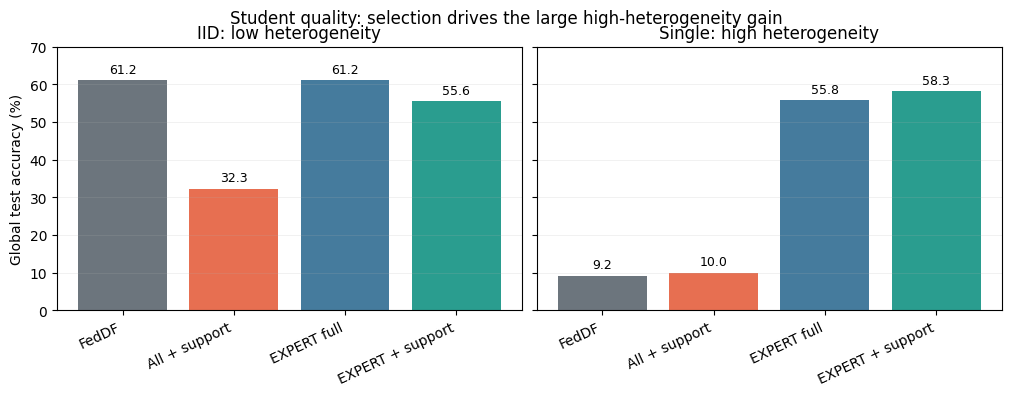

In [3]:
# Primary outcome: paired global-student accuracy.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharey=True, constrained_layout=True)
for ax, regime in zip(axes, ['iid', 'single']):
    frame = student[student.regime.eq(regime)].set_index('method').loc[methods]
    values = 100 * frame.test_accuracy.to_numpy()
    bars = ax.bar(range(len(methods)), values, color=[colors[m] for m in methods])
    ax.bar_label(bars, labels=[f'{value:.1f}' for value in values], padding=3, fontsize=9)
    ax.set_xticks(range(len(methods)), [labels[m] for m in methods], rotation=25, ha='right')
    ax.set_title('IID: low heterogeneity' if regime == 'iid' else 'Single: high heterogeneity')
    ax.set_ylim(0, 70)
    ax.grid(axis='y', alpha=.25)
axes[0].set_ylabel('Global test accuracy (%)')
fig.suptitle('Student quality: selection drives the large high-heterogeneity gain', y=1.03, fontsize=12);
plt.show()

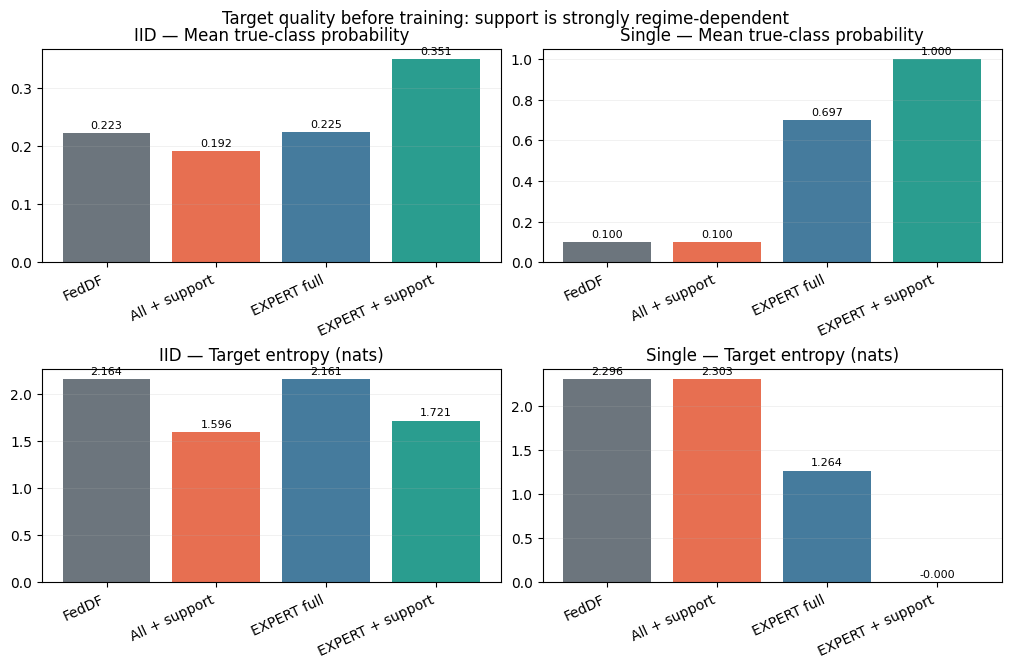

In [4]:
# Target-level mechanism: quality is visible before student training.
metrics = [('mean_probability_true_class', 'Mean true-class probability'), ('target_entropy', 'Target entropy (nats)')]
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4), constrained_layout=True)
for col, regime in enumerate(['iid', 'single']):
    frame = target[target.regime.eq(regime)].set_index('method').loc[methods]
    for row, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        values = frame[metric].to_numpy()
        bars = ax.bar(range(len(methods)), values, color=[colors[m] for m in methods])
        ax.bar_label(bars, labels=[f'{value:.3f}' for value in values], padding=2, fontsize=8)
        ax.set_xticks(range(len(methods)), [labels[m] for m in methods], rotation=25, ha='right')
        ax.set_title(('IID' if regime == 'iid' else 'Single') + ' — ' + title)
        ax.grid(axis='y', alpha=.25)
fig.suptitle('Target quality before training: support is strongly regime-dependent', y=1.02, fontsize=12);
plt.show()